# Regressão Linear # 

Principais Ideias:

1. Use o método de mínimos quadrados para ajustar um reta aos dados: Ajuste da reta.
2. Calcular R²: Determinar a precisão da estimativa da reta ajustada.
3. Calcular o p-valor para o R².

### Método de Mínimos Quadrados ### 

1. Trace uma linha através dos dados;
2. Meça a distância da linha até o ponto de dados **(resíduo)**. Eleve cada distância ao quadrado e some os resultados;
3. Gire (mude a angulação) da linha um pouco, com a nova linha meça os resíduos, eleve-os ao quadrado e some os quadrados.
4. Continue fazendo isso. 
5. Ao plotar a soma de resíduos em função das rotações, é possível encontrar a menor soma de quadrados dos resíduos.
6. Com isso, escolhemos essa reta com a menor soma de quadrados dos resíduos para ajustar os dados e obtemos a equação da reta **y = a + bx**. O parâmetro **a** é o valor em que eixo y é interceptado e a inclinação, já o parâmetro **b**.

### Soma dos Quadrados Entorno da Média ###

- Calcule a média da variável;
- Meça a distância da média até o ponto dos dados. Eleve ao quadrado e some os resultados;

### Soma dos Quadrados Entorno do Ajuste de Mínimos Quadrados ###

- Soma dos quadrados das distâncias entre os dados e a reta elevado ao quadrado; 
- Variança entorno do ajuste vezes o número de elementos;

### Cálculo R² ###


### Entregável obrigatório ### 

Escolher um problema de regressão (ex.: prever valor de imóvel, gasto mensal) e escrever uma hipótese de quais variáveis explicariam o alvo e por quê.

In [23]:
# Importando bibliotecas 

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [15]:
# Carregando base de dados

df = pd.read_csv("house-price-india.csv")
df

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14614,6762830250,42734,2,1.50,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14615,6762830339,42734,3,2.00,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14616,6762830618,42734,2,1.00,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14617,6762830709,42734,4,1.00,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000


In [16]:
# Verificar colunas e tipos 

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [17]:
# Estatísticas descritivas

print(df.columns)

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


**Hipóteses de variáveis explicativas para preço**:
- number of bedrooms / number of bathrooms > imóveis maiores e mais confortáveis tendem a custar mais caro.
- living area / lot area > área construída e tamanho do terreno influenciam diretamente o preço.
- number of floors > casas com mais andares podem ter maior valor agregado.
- waterfront present > imóveis próximos à água geralmente são mais valorizados. 
- number of views > pode indicar localização privilegiada ou marketing do imóvel.
- condition of the house / grade of the house > qualidade estrutural e padrão de acabamento impactam fortemente o preço.
- Built Year / Renovation Year → imóveis mais novos ou recentemente reformados tendem a valer mais.
- Location (Postal Code, Latitude, Longitude) > localização é um dos fatores mais importantes.
- Number of schools nearby / Distance from the airport > infraestrutura e acessibilidade influenciam o valor.

In [20]:
# Selecionando algumas variáveis explicativas

features = [
    "number of bedrooms",
    "number of bathrooms",
    "living area",
    "lot area",
    "number of floors",
    "condition of the house",
    "grade of the house",
    "Built Year",
    "Renovation Year",
    "Number of schools nearby",
    "Distance from the airport"    
]

X = df[features]
y = df["Price"]

In [21]:
# Adicionando a constante (intercepto)

X = sm.add_constant(X)

In [22]:
# Ajustando regressão linear

model = sm.OLS(y, X).fit()

# Resumo dos resultados

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     2266.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        22:17:57   Log-Likelihood:            -2.0079e+05
No. Observations:               14619   AIC:                         4.016e+05
Df Residuals:                   14607   BIC:                         4.017e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

**Resolução:**

*Qualidade geral do modelo:*
- R-squared: 0.630 > significa que cerca de 63% da variação no preço dos imóveis é explicada pelas variáveis escolhidas.
- Adj. R-squared: 0.630 > ajustado pelo número de variáveis, confirma que o modelo não está inflando artificialmente o poder explicativo.
- F-statistic: 2266, Prob(F-statistic): 0.00 > indica que o modelo como um todo é altamente significativo (as variáveis, em conjunto, explicam bem o preço).

*Interpretação dos coeficientes:*
- **const (intercepto): ~6.4 milhões**
Valor médio esperado do preço quando todas as variáveis são zero (não tem interpretação prática, mas serve como base).
- **number of bedrooms: -48.6 mil (significativo)**
Surpreendentemente, mais quartos reduzem o preço, possivelmente porque imóveis maiores já são capturados por living area e grade of the house. Isso sugere multicolinearidade.
- **number of bathrooms: +47.2 mil (significativo)**
Mais banheiros aumentam o preço, coerente com a ideia de maior conforto.
- **living area: +193 por unidade (significativo)**
Cada aumento de 1 unidade na área construída aumenta o preço em média em 193. Forte relação positiva.
- **lot area: -0.34 por unidade (significativo)**
Terrenos maiores reduzem o preço, o que parece contraintuitivo. Pode indicar que terrenos grandes estão em regiões menos valorizadas.
- **number of floors: +19.7 mil (significativo)**
Mais andares aumentam o preço, coerente com padrão construtivo.
- **condition of the house: +25.2 mil (significativo)**
Casas em melhor condição valem mais.
- **grade of the house: +126.9 mil (significativo)**
Padrão de acabamento é uma das variáveis mais fortes: casas de maior “grade” são muito mais caras.
- **Built Year: -3706 por ano (significativo)**
Quanto mais antigo o imóvel, menor o preço. Cada ano reduz em média 3.7 mil.
- **Renovation Year: +25 por ano (significativo)**
Reformas aumentam o preço, mas o efeito é pequeno comparado ao impacto da idade.
- **Number of schools nearby: +3674 (não significativo, p=0.104)**
A presença de escolas não tem efeito estatisticamente confiável no preço.
- **Distance from the airport: -106 (não significativo, p=0.608)**
A distância até o aeroporto também não explica o preço de forma significativa.

*Diagnósticos adicionais:*
- Omnibus, Jarque-Bera, Skew, Kurtosis > indicam que os resíduos não seguem distribuição normal (há assimetria e caudas pesadas).
- Durbin-Watson: 1.574 > sugere alguma autocorrelação nos resíduos (não ideal).
- Condition Number: 3.8e+06 > muito alto, indicando multicolinearidade (variáveis correlacionadas entre si, como bedrooms, bathrooms, living area). Isso pode distorcer os sinais dos coeficientes

*Conclusão:*
- O modelo explica bem os preços (63% da variabilidade).
- Variáveis mais importantes: living area, grade of the house, Built Year, number of bathrooms.
- Algumas variáveis têm sinais inesperados (ex.: bedrooms, lot area), provavelmente por multicolinearidade.
- schools nearby e distance from airport não são significativas.
- Há indícios de problemas estatísticos (resíduos não normais, multicolinearidade), então seria interessante testar modelos mais robustos (como regressão regularizada – Lasso/Ridge ou árvores de decisão).

### Entregável avançado ###

Em Python: treinar uma **regressão linear** simples (sklearn), mostrar coeficientes, R² e um gráfico de resíduos vs. preditos, comentando possíveis problemas (não linearidade, heterocedasticidade).


In [24]:
# Selecionando as variáveis explicativas 

X = df[["living area", "grade of the house","number of bathrooms"]]
y = df["Price"]

In [25]:
# Separando treino e teste 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Treinando o modelo de regressão linear

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Predições

y_pred = model.predict(X_test)

In [29]:
# Coeficientes

print("Intercepto:", model.intercept_)
print("Coeficientes:", dict(zip(X.columns, model.coef_)))

Intercepto: -596337.7082947693
Coeficientes: {'living area': 202.69458000634955, 'grade of the house': 102915.12154311816, 'number of bathrooms': -37892.13561551292}


In [30]:
# R2

print("R2 no conjunto de teste:", r2_score(y_test, y_pred))

R2 no conjunto de teste: 0.5667641203110786


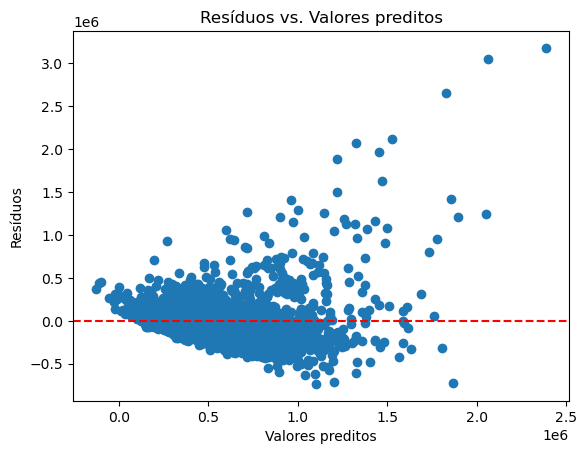

In [32]:
# Gráfico de resíduos vs. valores preditivos

residuos = y_test - y_pred
plt.scatter(y_pred, residuos)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores preditos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs. Valores preditos")
plt.show()

**Resolução:**

*Conclusão:*
- Coeficientes
    - O valor que intercepta o eixo y é o -596337.
    - **'living area':** 202.69458000634955 > **aumenta o preço**
    - **'grade of the house':** 102915.12154311816 > **aumenta o preço**
    - **'number of bathrooms':** -37892.13561551292 > **reduz o preço**
- R2
    - 0.5667 é razoável: o modelo explica mais da metade da variação dos preços, mas ainda deixa quase 43% sem explicação.
- Gráfico
    - O modelo linear explica parte da variação, mas não captura bem imóveis de preços mais altos (resíduos maiores), pois parece que os resíduos ficam mais dispersos em valores alto de preço, indicando que o modelo erra mais para imóveis caros.
    - Há indícios de heterocedasticidade: variância dos erros aumenta com o preço.
    - Pode haver não linearidade: o modelo linear não é suficiente para capturar todas as relações.

